In [36]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [37]:
from package.flows.online.flow import get_online_flow, Shared
from uuid import uuid4
from broflow import state

d:\broai-arai\backend\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🔍 Loading model from: BAAI/bge-m3


Fetching 30 files: 100%|██████████| 30/30 [00:00<?, ?it/s]


In [38]:
def generate_experiments(
    embed_methods=['raw'],
    chat_system_prompt_paths=['./package/flows/online/prompts/v1/chat.md'],
    term_detector_system_prompt_paths=["./package/flows/online/prompts/term_detector.md"],
    chat_models=[
            "us.meta.llama3-2-11b-instruct-v1:0",
        ],
    term_detector_models=["us.meta.llama3-2-11b-instruct-v1:0"]
):
    from itertools import product
    
    is_terms = ['skip', 'evidence', 'explanation']
    is_contexts = [True, False]
    
    experiments = []
    for (embed_method, chat_prompt, term_prompt, chat_model, term_model, 
         is_term, is_context) in product(
        embed_methods, chat_system_prompt_paths, term_detector_system_prompt_paths,
        chat_models, term_detector_models, is_terms, is_contexts
    ):
        base_config = {
            "embed_method": embed_method,
            "chat_system_prompt_path": chat_prompt,
            "term_detector_system_prompt_path": term_prompt,
            "chat_model": chat_model,
            "term_detector_model": term_model,
            "is_term": is_term,
            "is_context": is_context
        }
        
        if is_context:
            experiments.extend([
                {**base_config, "is_rerank": False},
                {**base_config, "is_rerank": True}
            ])
        else:
            experiments.append({**base_config, "is_rerank": False})
    
    return experiments


In [39]:
from dataclasses import dataclass, asdict

@dataclass
class ControlExperiment:
    chat_model:str
    chat_system_prompt_path:str
    term_detector_model:str
    term_detector_system_prompt_path:str
    embed_method:str
    is_term:str
    is_context:bool
    is_rerank:bool
    experiment_set:str

In [40]:
experiments = generate_experiments(
    embed_methods=['raw', 'combo'],
    chat_system_prompt_paths=['./package/flows/online/prompts/v1/chat.md'],
    term_detector_system_prompt_paths=["./package/flows/online/prompts/term_detector.md"],
    chat_models=[
        "us.meta.llama3-2-1b-instruct-v1:0",
        "us.meta.llama3-2-11b-instruct-v1:0",
        "us.meta.llama4-maverick-17b-instruct-v1:0",
        "us.meta.llama4-scout-17b-instruct-v1:0",
        "meta.llama3-3-70b-instruct-v1:0",
        "us.meta.llama3-2-90b-instruct-v1:0",
    ],
    term_detector_models=["us.meta.llama3-2-11b-instruct-v1:0"]
)
len(experiments)

108

In [41]:
len(experiments)

108

In [42]:
import json

with open("./dataset/trainset.json", 'r', encoding='utf-8') as f:
    trainset = json.load(f)

In [43]:
for ts in trainset:
    ts['metadata']['source'] = ts['metadata']['source'].replace(":", "")

In [ ]:
def one_experiment(ts, con_exp:ControlExperiment):
    _id = str(uuid4())
    experiment_storage = "./evaluations/{file}.json".format(file=_id)
    shared = Shared(
        experiment_id=_id,
        experiment_set=con_exp.experiment_set,
        question=ts['question'],
        answer=ts['answer'],
        type=ts['type'],
        source=ts['metadata']['source'],
        chat_model=con_exp.chat_model,
        term_detector_model=con_exp.term_detector_model,
        chat_system_prompt_path=con_exp.chat_system_prompt_path,
        term_detector_system_prompt_path=con_exp.term_detector_system_prompt_path,
        experiment_storage=experiment_storage,
        embed_method=con_exp.embed_method,
        is_term=con_exp.is_term,
        is_context=con_exp.is_context,
        is_rerank=con_exp.is_rerank

    )

    flow = get_online_flow(experiment=shared.experiment_id)
    flow.run(shared)    

def main(trainset, experiments):
    for experiment in experiments:
        experiment.update({"experiment_set":str(uuid4())})
        con_exp = ControlExperiment(**experiment)
        for ts in trainset:
            one_experiment(ts, con_exp)

In [29]:
state.set('debug', False)
main(trainset[0:1], experiments[0:1])

Start bbc42273-a0ab-419f-84a1-538376eeb2a2


d:\broai-arai\backend\.venv\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `XLMRobertaSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


End bbc42273-a0ab-419f-84a1-538376eeb2a2


In [1]:
import json
import glob
import pandas as pd

def load_evaluations_to_dataframe(evaluations_dir="./experiments/sixth_evaluations"):
    data = []
    
    for file_path in glob.glob(f"{evaluations_dir}/*.json"):
        with open(file_path, 'r') as f:
            record = json.load(f)
        
        # Extract and flatten evaluation metrics
        if 'evaluation' in record:
            eval_data = record.pop('evaluation')
            for metric, values in eval_data.items():
                if isinstance(values, dict):
                    for sub_metric, value in values.items():
                        record[f"eval_{metric}_{sub_metric}"] = value
                else:
                    record[f"eval_{metric}"] = values
        
        data.append(record)
    
    df = pd.DataFrame(data)
    df.insert(0, "experiment", evaluations_dir.split("/")[-1])
    return df


In [ ]:
df = load_evaluations_to_dataframe()

In [30]:
experiments = [
    './experiments/fifth_evaluations', 
    # './experiments/sixth_evaluations'
]
df = pd.concat([load_evaluations_to_dataframe(exp) for exp in experiments], axis=0, ignore_index=True)
df.shape

(1188, 40)

In [31]:
df.to_csv('completed_experiments.csv', index=False)

In [32]:
df.head()

,experiment,question,answer,type,source,experiment_id,experiment_set,experiment_storage,document_id,document_source,...,eval_rougeL_precision,eval_rougeL_recall,eval_rougeL_fmeasure,eval_rougeLsum_precision,eval_rougeLsum_recall,eval_rougeLsum_fmeasure,eval_hotpot_em,eval_hotpot_f1,eval_hotpot_precision,eval_hotpot_recall
0,fifth_evaluations,What is LOGICOL?,LOGICOL is a logically-informed contrastive le...,explanation,LOGICOL Logically-Informed Contrastive Learnin...,005ba099-bc7d-44b1-9bf6-059c9190d84d,9c5f9735-db7e-4376-a5e7-e7759b8e8a0b,./experiments/fifth_evaluations/005ba099-bc7d-...,df47df55-be76-403e-b7c8-fc57d0e3935c,LOGICOL Logically-Informed Contrastive Learnin...,...,0.164384,0.800000,0.272727,0.164384,0.800000,0.272727,0.0,0.311688,0.187500,0.923077
1,fifth_evaluations,What does STORM stand for?,Synthesis of Topic Outlines through Retrieval ...,acronym,Assisting in Writing Wikipedia-like Articles F...,00963422-0a81-453e-bf01-a8ccdc701488,f49ea452-7686-4c61-95dc-0fcd41ef1ce3,./experiments/fifth_evaluations/00963422-0a81-...,8170f3b0-9203-4ec2-8dcc-476eeb9c69b0,Assisting in Writing Wikipedia-like Articles F...,...,0.785714,1.000000,0.880000,0.785714,1.000000,0.880000,0.0,0.869565,0.769231,1.000000
2,fifth_evaluations,What is POQD?,POQD is a novel query decomposition framework ...,explanation,POQD Performance-Oriented Query Decomposer for...,00a119c0-9cf3-40e1-8da9-8dfa5d15ff48,60a34ecb-a509-4f0d-bf6f-72f8a6d4e15a,./experiments/fifth_evaluations/00a119c0-9cf3-...,c15d3840-4701-4cc8-9842-2debdd453381,POQD Performance-Oriented Query Decomposer for...,...,0.144578,0.666667,0.237624,0.144578,0.666667,0.237624,0.0,0.298851,0.183099,0.812500
3,fifth_evaluations,What is MASKSEARCH?,MASKSEARCH is a universal pre-training framewo...,explanation,MASKSEARCH A Universal Pre-Training Framework ...,00ef5b60-ec89-4217-87b5-fd2148e5a55c,1075ce17-013f-46b6-a315-1579f101f786,./experiments/fifth_evaluations/00ef5b60-ec89-...,9b8418e9-6f5f-4116-b3ed-7eef0b58c34c,MASKSEARCH A Universal Pre-Training Framework ...,...,0.267857,0.714286,0.389610,0.267857,0.714286,0.389610,0.0,0.393939,0.265306,0.764706
4,fifth_evaluations,What is STORM?,STORM is a writing system for the Synthesis of...,explanation,Assisting in Writing Wikipedia-like Articles F...,00f2ea66-01ba-45e6-bbf1-b370669de045,b3002635-bda5-4f61-8f85-533be2845275,./experiments/fifth_evaluations/00f2ea66-01ba-...,8170f3b0-9203-4ec2-8dcc-476eeb9c69b0,Assisting in Writing Wikipedia-like Articles F...,...,0.054688,0.388889,0.095890,0.054688,0.388889,0.095890,0.0,0.075758,0.042735,0.333333


In [33]:
def average_evaluation_metrics_by_experiment_set(df, grp_col=['experiment_set']):
    eval_columns = [col for col in df.columns if col.startswith('eval_')]
    numeric_eval_columns = df[eval_columns].select_dtypes(include=['number']).columns
    return df.groupby(grp_col)[numeric_eval_columns].mean().reset_index()

grp_col = [
    'experiment',
    'experiment_set',
    'type',
    'chat_model',
    'is_term',
    'is_context',
    'is_rerank',
]
grp = average_evaluation_metrics_by_experiment_set(df, grp_col=grp_col)

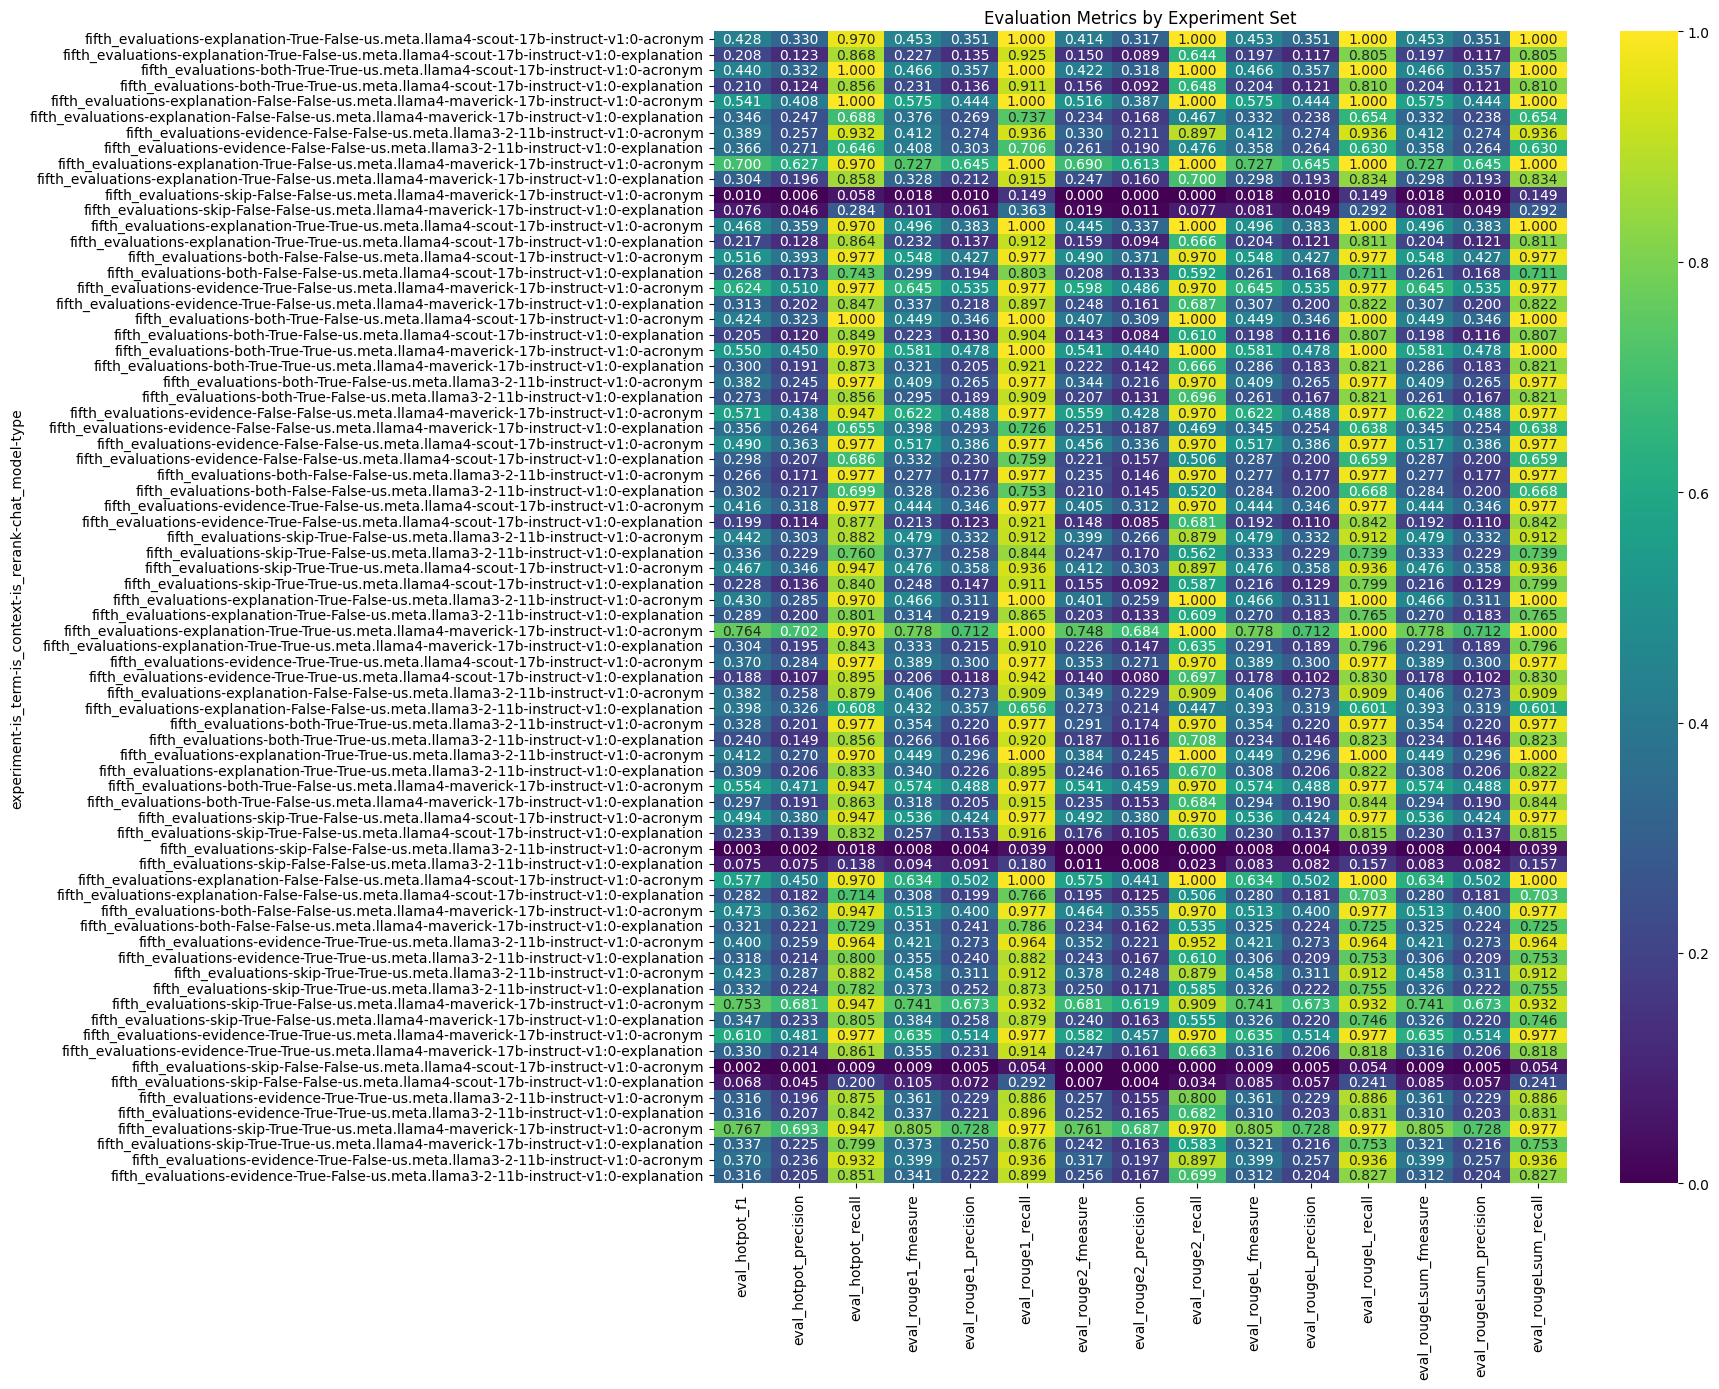

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

def visualize_metrics(grp, set_index=['experiment_set'], suffixes=['_f1','_fmeasure', '_recall', '_precision']):
    eval_cols = [col for col in grp.columns if col.startswith('eval_') 
                 and any(col.endswith(suffix) for suffix in suffixes)]
    eval_cols = sorted(eval_cols)
    pivot_data = grp.set_index(set_index)[eval_cols]
    
    plt.figure(figsize=(18, 14))
    sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='viridis')
    plt.title('Evaluation Metrics by Experiment Set')
    plt.tight_layout()
    plt.show()



# Quick ranking
def rank_experiments(grp, metric='eval_rouge1_fmeasure'):
    return grp.nlargest(10, metric)[['experiment_set', metric]]

# Usage examples:
visualize_metrics(grp, 
    # suffixes=[
    # # '_f1', 
    # # '_fmeasure',
    # # '_recall',
    # # '_precision',
    # ],
    set_index=[
        'experiment',
        'is_term',
        'is_context',
        'is_rerank',
        'chat_model',
        'type',
    ]
)

In [35]:
grp.columns

Index(['experiment', 'experiment_set', 'type', 'chat_model', 'is_term',
       'is_context', 'is_rerank', 'eval_rouge1_precision',
       'eval_rouge1_recall', 'eval_rouge1_fmeasure', 'eval_rouge2_precision',
       'eval_rouge2_recall', 'eval_rouge2_fmeasure', 'eval_rougeL_precision',
       'eval_rougeL_recall', 'eval_rougeL_fmeasure',
       'eval_rougeLsum_precision', 'eval_rougeLsum_recall',
       'eval_rougeLsum_fmeasure', 'eval_hotpot_em', 'eval_hotpot_f1',
       'eval_hotpot_precision', 'eval_hotpot_recall'],
      dtype='object')

In [36]:
target_cols = ['experiment', 'experiment_set', 'chat_model', 'is_term', 'is_context', 'is_rerank', 'type']

In [43]:
cols = list(grp.columns[grp.columns.str.endswith("_recall")])
cols

['eval_rouge1_recall',
 'eval_rouge2_recall',
 'eval_rougeL_recall',
 'eval_rougeLsum_recall',
 'eval_hotpot_recall']

In [46]:
metric = 'rougeL'
_metric_typ = 'recall'

grp_col = [
    'experiment',
    'experiment_set',
    # 'type',
    'chat_model',
    'is_term',
    'is_context',
    'is_rerank',
]
grp = average_evaluation_metrics_by_experiment_set(df, grp_col=grp_col)
mask = grp['is_context'] == True
mask &= grp['is_rerank'] == True
col = f'eval_{metric}_{_metric_typ}'.format(metric=metric, _metric_typ=_metric_typ)
grp.loc[mask, target_cols[:-1]+cols].nlargest(30, col)

,experiment,experiment_set,chat_model,is_term,is_context,is_rerank,eval_rouge1_recall,eval_rouge2_recall,eval_rougeL_recall,eval_rougeLsum_recall,eval_hotpot_recall
23,fifth_evaluations,94b81a1c-782d-42c0-9e89-ebe418683680,us.meta.llama3-2-11b-instruct-v1:0,explanation,True,True,0.929672,0.780008,0.881135,0.881135,0.878401
10,fifth_evaluations,411900cc-455d-4f0a-a05b-39e2f448cab2,us.meta.llama4-maverick-17b-instruct-v1:0,both,True,True,0.947256,0.777186,0.880826,0.880826,0.905522
20,fifth_evaluations,8190377d-8362-4467-871e-3242dee4fb1b,us.meta.llama4-scout-17b-instruct-v1:0,evidence,True,True,0.953454,0.787607,0.878791,0.878791,0.922414
22,fifth_evaluations,8ea35458-8365-4ad1-99d6-e6c5c12f4f18,us.meta.llama3-2-11b-instruct-v1:0,both,True,True,0.938866,0.794932,0.874747,0.874747,0.896389
6,fifth_evaluations,264a77e8-3ee7-443e-9124-114762f75f90,us.meta.llama4-scout-17b-instruct-v1:0,explanation,True,True,0.941511,0.777005,0.874196,0.874196,0.899451
1,fifth_evaluations,036536d6-420d-4238-9183-e0c59136ab17,us.meta.llama4-scout-17b-instruct-v1:0,both,True,True,0.940394,0.765625,0.873496,0.873496,0.904051
32,fifth_evaluations,d00021f9-5e24-428b-b4fd-90adbe088d5b,us.meta.llama4-maverick-17b-instruct-v1:0,evidence,True,True,0.935131,0.765365,0.870972,0.870972,0.899972
19,fifth_evaluations,75a3ff4e-95f5-4009-ab80-7dcba57e8d9c,us.meta.llama4-maverick-17b-instruct-v1:0,explanation,True,True,0.940185,0.756675,0.863688,0.863688,0.884907
34,fifth_evaluations,e91524b0-2c04-4612-8c72-ac979f3cec88,us.meta.llama3-2-11b-instruct-v1:0,evidence,True,True,0.893602,0.711159,0.845023,0.845023,0.850074
17,fifth_evaluations,61f91994-a6f1-4a59-bf97-d8b39b61806d,us.meta.llama4-scout-17b-instruct-v1:0,skip,True,True,0.919395,0.690552,0.844374,0.844374,0.875817


In [47]:
new = 0.808928
old = 0.854191
((new-old)/old)

-0.052989319718891974

In [48]:
grp_col = [
    'experiment',
    'experiment_set',
    'type',
    'chat_model',
    'is_term',
    'is_context',
    'is_rerank',
]
grp = average_evaluation_metrics_by_experiment_set(df, grp_col=grp_col)

mask = grp['type'] == 'acronym'
# col = f'eval_{metric}_{_metric_typ}'.format(metric=metric, _metric_typ=_metric_typ)
grp.loc[mask, target_cols+cols].nlargest(20, col)

,experiment,experiment_set,chat_model,is_term,is_context,is_rerank,type,eval_rouge1_recall,eval_rouge2_recall,eval_rougeL_recall,eval_rougeLsum_recall,eval_hotpot_recall
0,fifth_evaluations,01b02d4e-3233-4532-a624-dc3d5b1fd9fc,us.meta.llama4-scout-17b-instruct-v1:0,explanation,True,False,acronym,1.000000,1.000000,1.000000,1.000000,0.969697
2,fifth_evaluations,036536d6-420d-4238-9183-e0c59136ab17,us.meta.llama4-scout-17b-instruct-v1:0,both,True,True,acronym,1.000000,1.000000,1.000000,1.000000,1.000000
4,fifth_evaluations,1075ce17-013f-46b6-a315-1579f101f786,us.meta.llama4-maverick-17b-instruct-v1:0,explanation,False,False,acronym,1.000000,1.000000,1.000000,1.000000,1.000000
8,fifth_evaluations,16207ad6-730a-4c85-9401-bbd2bf90e8ec,us.meta.llama4-maverick-17b-instruct-v1:0,explanation,True,False,acronym,1.000000,1.000000,1.000000,1.000000,0.969697
12,fifth_evaluations,264a77e8-3ee7-443e-9124-114762f75f90,us.meta.llama4-scout-17b-instruct-v1:0,explanation,True,True,acronym,1.000000,1.000000,1.000000,1.000000,0.969697
18,fifth_evaluations,37f53863-635c-4ce8-83d0-8de84cdcd94d,us.meta.llama4-scout-17b-instruct-v1:0,both,True,False,acronym,1.000000,1.000000,1.000000,1.000000,1.000000
20,fifth_evaluations,411900cc-455d-4f0a-a05b-39e2f448cab2,us.meta.llama4-maverick-17b-instruct-v1:0,both,True,True,acronym,1.000000,1.000000,1.000000,1.000000,0.969697
36,fifth_evaluations,74763a11-2f80-4718-bf22-c1b4149ab9b3,us.meta.llama3-2-11b-instruct-v1:0,explanation,True,False,acronym,1.000000,1.000000,1.000000,1.000000,0.969697
38,fifth_evaluations,75a3ff4e-95f5-4009-ab80-7dcba57e8d9c,us.meta.llama4-maverick-17b-instruct-v1:0,explanation,True,True,acronym,1.000000,1.000000,1.000000,1.000000,0.969697
46,fifth_evaluations,94b81a1c-782d-42c0-9e89-ebe418683680,us.meta.llama3-2-11b-instruct-v1:0,explanation,True,True,acronym,1.000000,1.000000,1.000000,1.000000,0.969697


In [49]:
new = 1
old = 0.977273
((new-old)/old)

0.023255528393806086

In [50]:
mask = grp['type'] != 'acronym'
# col = f'eval_{metric}_{_metric_typ}'.format(metric=metric, _metric_typ=_metric_typ)
grp.loc[mask, target_cols+cols].nlargest(20, col)

,experiment,experiment_set,chat_model,is_term,is_context,is_rerank,type,eval_rouge1_recall,eval_rouge2_recall,eval_rougeL_recall,eval_rougeLsum_recall,eval_hotpot_recall
49,fifth_evaluations,9c5f9735-db7e-4376-a5e7-e7759b8e8a0b,us.meta.llama4-maverick-17b-instruct-v1:0,both,True,False,explanation,0.915408,0.683970,0.844098,0.844098,0.862729
31,fifth_evaluations,567cf946-2c5a-48bc-b28e-f5d0f870d3b9,us.meta.llama4-scout-17b-instruct-v1:0,evidence,True,False,explanation,0.921349,0.681413,0.842308,0.842308,0.877077
9,fifth_evaluations,16207ad6-730a-4c85-9401-bbd2bf90e8ec,us.meta.llama4-maverick-17b-instruct-v1:0,explanation,True,False,explanation,0.915396,0.700190,0.834231,0.834231,0.858456
69,fifth_evaluations,e91524b0-2c04-4612-8c72-ac979f3cec88,us.meta.llama3-2-11b-instruct-v1:0,evidence,True,True,explanation,0.896014,0.681545,0.831243,0.831243,0.841765
41,fifth_evaluations,8190377d-8362-4467-871e-3242dee4fb1b,us.meta.llama4-scout-17b-instruct-v1:0,evidence,True,True,explanation,0.941544,0.696561,0.829550,0.829550,0.894984
73,fifth_evaluations,fcba4af2-bb7c-4c44-a769-8a9db0742fa9,us.meta.llama3-2-11b-instruct-v1:0,evidence,True,False,explanation,0.899274,0.699495,0.827207,0.827207,0.850776
45,fifth_evaluations,8ea35458-8365-4ad1-99d6-e6c5c12f4f18,us.meta.llama3-2-11b-instruct-v1:0,both,True,True,explanation,0.919663,0.707550,0.823484,0.823484,0.855947
47,fifth_evaluations,94b81a1c-782d-42c0-9e89-ebe418683680,us.meta.llama3-2-11b-instruct-v1:0,explanation,True,True,explanation,0.894508,0.670012,0.821703,0.821703,0.832754
17,fifth_evaluations,3316e6dc-dc58-4690-b55e-5e63747c49ad,us.meta.llama4-maverick-17b-instruct-v1:0,evidence,True,False,explanation,0.896697,0.686509,0.821664,0.821664,0.846645
21,fifth_evaluations,411900cc-455d-4f0a-a05b-39e2f448cab2,us.meta.llama4-maverick-17b-instruct-v1:0,both,True,True,explanation,0.920885,0.665778,0.821240,0.821240,0.873434


In [42]:
new = 0.844098
old = 0.831243
(new-old)/old

0.015464791883961803

In [64]:
df.shape, grp.shape

((1188, 39), (74, 22))

In [52]:
grp.columns

Index(['experiment', 'experiment_set', 'type', 'chat_model', 'is_term',
       'is_context', 'is_rerank', 'eval_rouge1_precision',
       'eval_rouge1_recall', 'eval_rouge1_fmeasure', 'eval_rouge2_precision',
       'eval_rouge2_recall', 'eval_rouge2_fmeasure', 'eval_rougeL_precision',
       'eval_rougeL_recall', 'eval_rougeL_fmeasure',
       'eval_rougeLsum_precision', 'eval_rougeLsum_recall',
       'eval_rougeLsum_fmeasure', 'eval_hotpot_em', 'eval_hotpot_f1',
       'eval_hotpot_precision', 'eval_hotpot_recall'],
      dtype='object')

In [60]:
metrics = [
    "eval_rougeL_recall"
]
aggs = {str(met):pd.NamedAgg(column=met, aggfunc='mean') for met in metrics}
mask = df['type'] == 'acronym'
df.loc[mask,:].groupby(['chat_model', 'is_term','is_context', 'is_rerank']).agg(**aggs).reset_index().sort_values('eval_rougeL_recall', ascending=False)

,chat_model,is_term,is_context,is_rerank,eval_rougeL_recall
14,us.meta.llama4-maverick-17b-instruct-v1:0,both,True,True,1.000000
19,us.meta.llama4-maverick-17b-instruct-v1:0,explanation,True,False,1.000000
8,us.meta.llama3-2-11b-instruct-v1:0,explanation,True,True,1.000000
7,us.meta.llama3-2-11b-instruct-v1:0,explanation,True,False,1.000000
31,us.meta.llama4-scout-17b-instruct-v1:0,explanation,True,False,1.000000
30,us.meta.llama4-scout-17b-instruct-v1:0,explanation,False,False,1.000000
32,us.meta.llama4-scout-17b-instruct-v1:0,explanation,True,True,1.000000
20,us.meta.llama4-maverick-17b-instruct-v1:0,explanation,True,True,1.000000
18,us.meta.llama4-maverick-17b-instruct-v1:0,explanation,False,False,1.000000
26,us.meta.llama4-scout-17b-instruct-v1:0,both,True,True,1.000000


In [61]:
df.columns

Index(['experiment', 'question', 'answer', 'type', 'source', 'experiment_id',
       'experiment_set', 'experiment_storage', 'document_id',
       'document_source', 'chat_system_prompt', 'chat_message_prompt',
       'potential_terms', 'detailed_terms', 'contexts', 'predict',
       'chat_model', 'chat_system_prompt_path', 'term_detector_model',
       'term_detector_system_prompt_path', 'embed_method', 'is_term',
       'is_context', 'is_rerank', 'eval_rouge1_precision',
       'eval_rouge1_recall', 'eval_rouge1_fmeasure', 'eval_rouge2_precision',
       'eval_rouge2_recall', 'eval_rouge2_fmeasure', 'eval_rougeL_precision',
       'eval_rougeL_recall', 'eval_rougeL_fmeasure',
       'eval_rougeLsum_precision', 'eval_rougeLsum_recall',
       'eval_rougeLsum_fmeasure', 'eval_hotpot_em', 'eval_hotpot_f1',
       'eval_hotpot_precision', 'eval_hotpot_recall'],
      dtype='object')

In [68]:
df.columns

Index(['experiment', 'question', 'answer', 'type', 'source', 'experiment_id',
       'experiment_set', 'experiment_storage', 'document_id',
       'document_source', 'chat_system_prompt', 'chat_message_prompt',
       'potential_terms', 'detailed_terms', 'contexts', 'predict',
       'chat_model', 'chat_system_prompt_path', 'term_detector_model',
       'term_detector_system_prompt_path', 'embed_method', 'is_term',
       'is_context', 'is_rerank', 'eval_rouge1_precision',
       'eval_rouge1_recall', 'eval_rouge1_fmeasure', 'eval_rouge2_precision',
       'eval_rouge2_recall', 'eval_rouge2_fmeasure', 'eval_rougeL_precision',
       'eval_rougeL_recall', 'eval_rougeL_fmeasure',
       'eval_rougeLsum_precision', 'eval_rougeLsum_recall',
       'eval_rougeLsum_fmeasure', 'eval_hotpot_em', 'eval_hotpot_f1',
       'eval_hotpot_precision', 'eval_hotpot_recall'],
      dtype='object')

In [71]:
target_cols = [
    'chat_model', 'answer', 'predict', 'is_term', 'is_context', 'is_rerank', 
        # 'eval_rouge1_precision',
       'eval_rouge1_recall', 
    #    'eval_rouge1_fmeasure', 'eval_rouge2_precision',
       'eval_rouge2_recall', 
    #    'eval_rouge2_fmeasure', 'eval_rougeL_precision',
       'eval_rougeL_recall', 
    #    'eval_rougeL_fmeasure',
    #    'eval_rougeLsum_precision', 'eval_rougeLsum_recall',
    #    'eval_rougeLsum_fmeasure', 'eval_hotpot_em', 'eval_hotpot_f1',
    #    'eval_hotpot_precision', 
       'eval_hotpot_recall'    
]
mask = True
# mask &= df['experiment_set']=='8190377d-8362-4467-871e-3242dee4fb1b'
mask &= df['question'] == 'What does DiscoVLA stand for?'
df.loc[mask, target_cols]

,chat_model,answer,predict,is_term,is_context,is_rerank,eval_rouge1_recall,eval_rouge2_recall,eval_rougeL_recall,eval_hotpot_recall
19,us.meta.llama4-scout-17b-instruct-v1:0,"Discrepancy Reduction in Vision, Language, and...",DiscoVLA stands for Discrepancy Reduction in V...,evidence,True,True,1.000000,1.0,1.000000,1.000000
21,us.meta.llama4-maverick-17b-instruct-v1:0,"Discrepancy Reduction in Vision, Language, and...",DiscoVLA stands for Discrepancy Reduction in V...,explanation,True,False,1.000000,1.0,1.000000,1.000000
43,us.meta.llama4-maverick-17b-instruct-v1:0,"Discrepancy Reduction in Vision, Language, and...",DiscoVLA stands for Discrepancy Reduction in V...,both,True,False,1.000000,1.0,1.000000,1.000000
87,us.meta.llama3-2-11b-instruct-v1:0,"Discrepancy Reduction in Vision, Language, and...",Based on the provided TERMS and CONTEXTS infor...,evidence,True,False,1.000000,1.0,1.000000,1.000000
102,us.meta.llama4-scout-17b-instruct-v1:0,"Discrepancy Reduction in Vision, Language, and...",DiscoVLA stands for Discrepancy Reduction in V...,both,True,True,1.000000,1.0,1.000000,1.000000
147,us.meta.llama4-maverick-17b-instruct-v1:0,"Discrepancy Reduction in Vision, Language, and...",DiscoVLA stands for Discrepancy Reduction in V...,evidence,True,False,1.000000,1.0,1.000000,1.000000
194,us.meta.llama4-scout-17b-instruct-v1:0,"Discrepancy Reduction in Vision, Language, and...",DiscoVLA stands for Discrepancy Reduction in V...,both,True,False,1.000000,1.0,1.000000,1.000000
247,us.meta.llama4-maverick-17b-instruct-v1:0,"Discrepancy Reduction in Vision, Language, and...",DiscoVLA stands for Discrepancy Reduction in V...,explanation,True,True,1.000000,1.0,1.000000,1.000000
278,us.meta.llama3-2-11b-instruct-v1:0,"Discrepancy Reduction in Vision, Language, and...","Based on the provided CONTEXTS, DiscoVLA stand...",skip,True,True,0.285714,0.0,0.285714,0.285714
354,us.meta.llama4-maverick-17b-instruct-v1:0,"Discrepancy Reduction in Vision, Language, and...",DiscoVLA stands for Discrepancy Reduction in V...,explanation,False,False,1.000000,1.0,1.000000,1.000000
